In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [50]:
ado = np.loadtxt("./adatok/ado.dat")

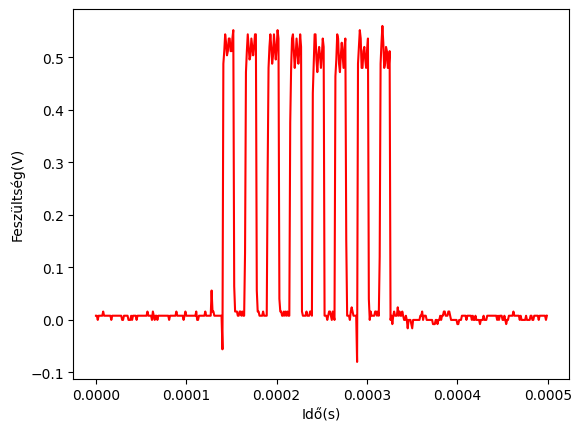

In [51]:
plt.plot(ado[:,0], ado[:,2], c="r")
plt.xlabel("Idő(s)")
plt.ylabel("Feszültség(V)")
plt.show()

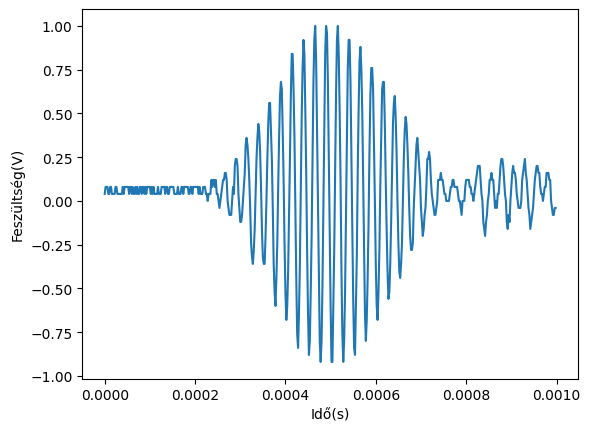

In [52]:
vevo = np.loadtxt("./adatok/vevo.dat")
plt.plot(vevo[:,0], vevo[:,3])
plt.xlabel("Idő(s)")
plt.ylabel("Feszültség(V)")
plt.show()

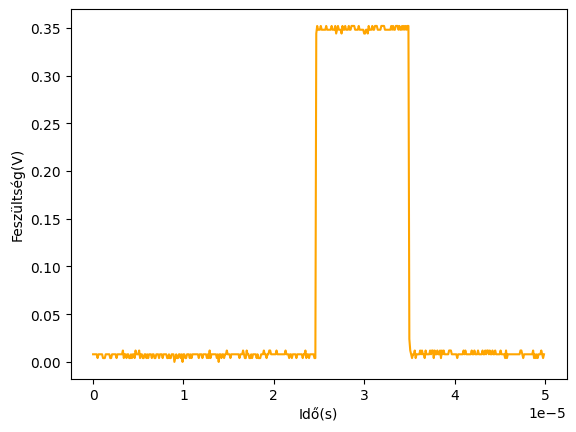

In [53]:
trigger = np.loadtxt("./adatok/trigger.dat")
plt.plot(trigger[:,0], trigger[:,1], c="orange")
plt.xlabel("Idő(s)")
plt.ylabel("Feszültség(V)")
plt.show()

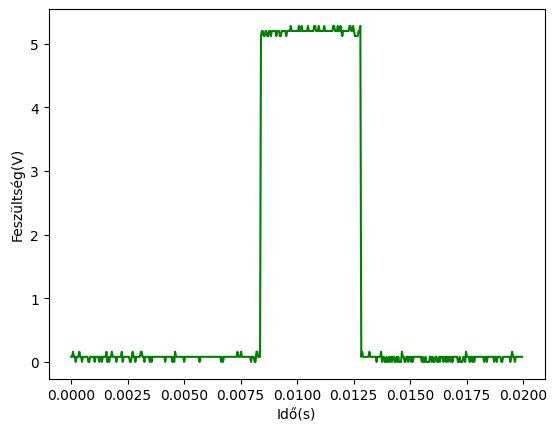

In [54]:
echo = np.loadtxt("./adatok/echo.dat")
plt.plot(echo[:,0], echo[:,4], c="g")
plt.xlabel("Idő(s)")
plt.ylabel("Feszültség(V)")
plt.show()

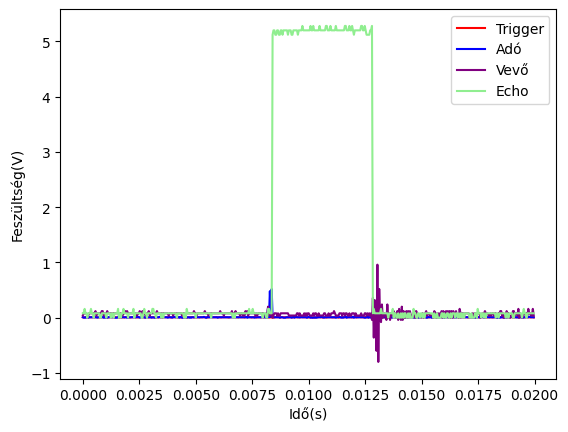

In [55]:
plt.plot(echo[:,0], echo[:,1], label="Trigger", c="red")
plt.plot(echo[:,0], echo[:,2], label="Adó", c="blue")
plt.plot(echo[:,0], echo[:,3], label="Vevő", c="purple")
plt.plot(echo[:,0], echo[:,4], label="Echo", c="lightgreen")
plt.xlabel("Idő(s)")
plt.ylabel("Feszültség(V)")
plt.legend()
plt.show()

In [56]:
print(max(echo[:,1]))

0.012


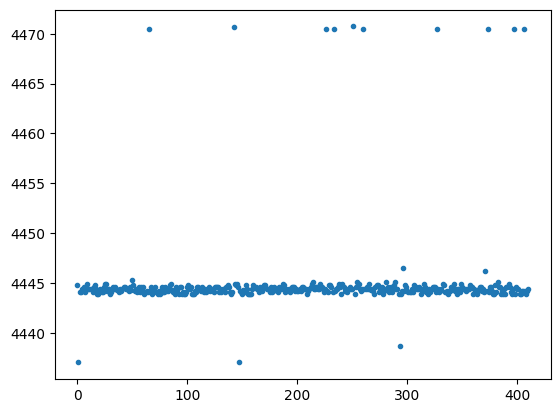

In [57]:
ismerkedes = np.loadtxt("./adatok/ismerkedes.dat")
plt.plot(ismerkedes[:,0], ".")

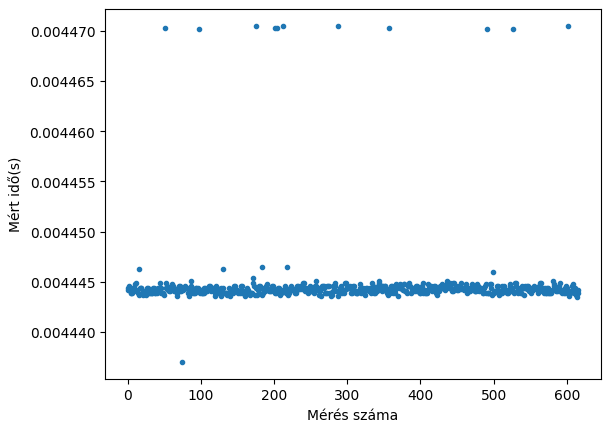

In [58]:
alapvonal = np.loadtxt("./adatok/alapvonal.dat")
plt.plot(alapvonal[:,0] * 1e-6, ".")
plt.xlabel("Mérés száma")
plt.ylabel("Mért idő(s)")
plt.show()

In [59]:
def szuro(x):
    rendezett = x[x[:,0].argsort()]
    minta_ertek = rendezett[:,0][int(len(x)/3)]
    eredmeny = [i for i in rendezett if (i[0] <= minta_ertek + 5 and i[0] >= minta_ertek - 5)]
    return eredmeny


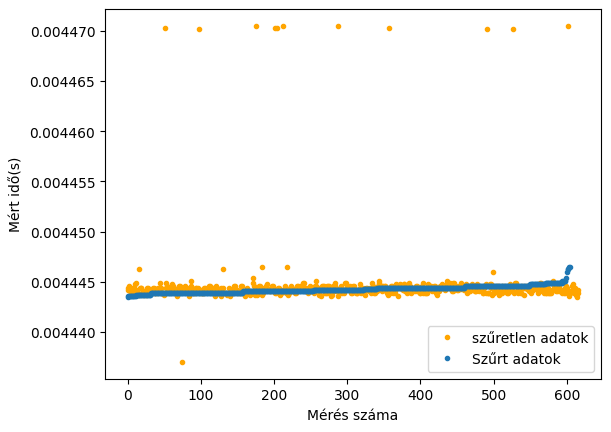

In [60]:
plt.plot(alapvonal[:,0]*1e-6, ".", c="orange", label="szűretlen adatok")
plt.plot(np.array(szuro(alapvonal))[:,0]*1e-6, ".", label="Szűrt adatok")
plt.xlabel("Mérés száma")
plt.ylabel("Mért idő(s)")
plt.legend()
plt.show()

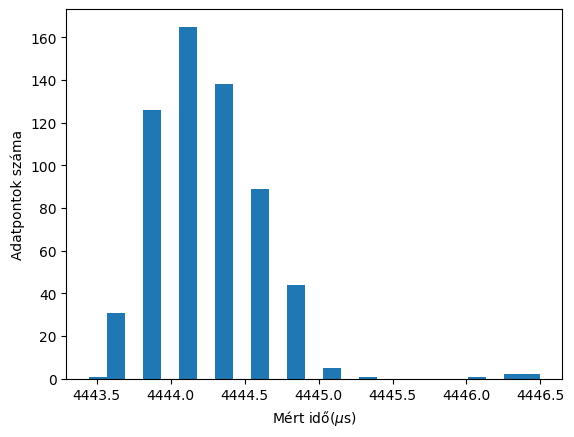

0.1392797598281554
12.140470721199534


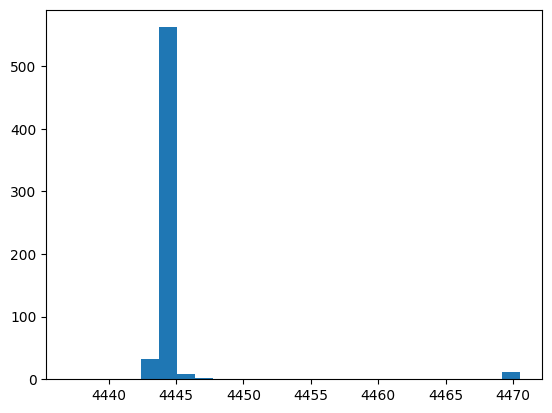

In [61]:
plt.hist(np.array(szuro(alapvonal))[:,0], bins=25)
plt.xlabel("Mért idő($\\mu$s)")
plt.ylabel("Adatpontok száma")
plt.show()
plt.hist(np.array((alapvonal))[:,0], bins=25)
print(np.var(np.array(szuro(alapvonal))[:,0]))
print(np.var((alapvonal)[:,0]))

In [62]:
meresek = [np.array(szuro(np.loadtxt("./adatok/meres_" + str(i) + ".dat"))) for i in range(1, 10)]
meres_atlagok = np.array([np.average(i[:,0]) for i in meresek]) * 1e-6
meres_szorasok = np.array([np.var(i[:,1]) for i in meresek]) * 1e-6
meresek_tavolsaga = np.array([0, 9.9, 19.6, 29.9, 39.6, 50.3, 59.8, 70.8, 80.4]) / 100

In [63]:
for i in range(len(meres_atlagok)):
    print(meresek_tavolsaga[i], end=" & ")
    print(meres_atlagok[i], end=" & ")
    print(meres_szorasok[i], end=" ")
    print("\\\\")

0.0 & 0.004444258823140496 & 0.0 \\
0.099 & 0.004747772093093093 & 4.039089765441117e-10 \\
0.196 & 0.005054371701719198 & 9.698196238126124e-10 \\
0.299 & 0.005326332358614233 & 5.764388615354403e-11 \\
0.396 & 0.005624378429377431 & 9.06169094157368e-10 \\
0.503 & 0.005936836026923076 & 6.390228289910637e-10 \\
0.598 & 0.006178582485344826 & 0.0 \\
0.708 & 0.006494640225198938 & 0.0 \\
0.804 & 0.006795887947744362 & 4.3547543671208097e-10 \\


Text(0, 0.5, 'Futási idők átlaga(s)')

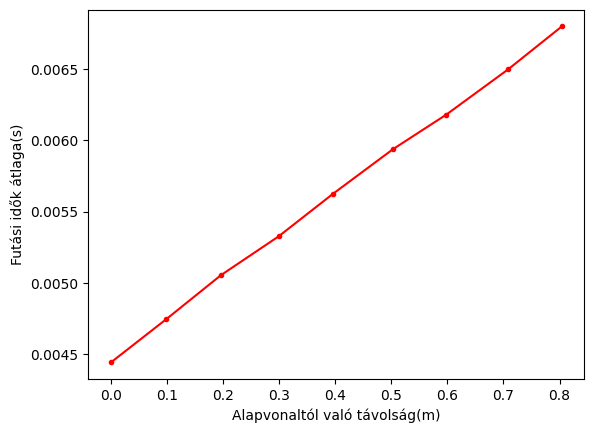

In [64]:
plt.plot(meresek_tavolsaga, meres_atlagok, "r.-")
plt.xlabel("Alapvonaltól való távolság(m)")
plt.ylabel("Futási idők átlaga(s)")

In [65]:
def linearis(l, c, a):
    return l * c + a

In [66]:
print(meres_szorasok)

[0.00000000e+00 4.03908977e-10 9.69819624e-10 5.76438862e-11
 9.06169094e-10 6.39022829e-10 0.00000000e+00 0.00000000e+00
 4.35475437e-10]


In [67]:
hangsebesseg_illesztes = curve_fit(linearis, meres_atlagok, meresek_tavolsaga)
print(hangsebesseg_illesztes[0])
print(np.sqrt(np.diag(hangsebesseg_illesztes[1])))

[345.54829426  -1.54253346]
[2.62276781 0.0148785 ]


In [68]:
doppler_meresek = []
doppler_meresek.append(np.array(szuro(np.loadtxt("./adatok/doppler_2.dat"))))
doppler_meresek.append(np.array(szuro(np.loadtxt("./adatok/doppler_1.dat"))))
doppler_meresek.append(np.array(szuro(np.loadtxt("./adatok/doppler_3.dat"))))

In [69]:
doppler_atlagok = np.array([np.average(i[:,0]) for i in doppler_meresek])
doppler_szorasok = np.array([np.var(i[:,0]) for i in doppler_meresek])
ventillator_fordulatszamok = [303.0, 400.0, 463.0]

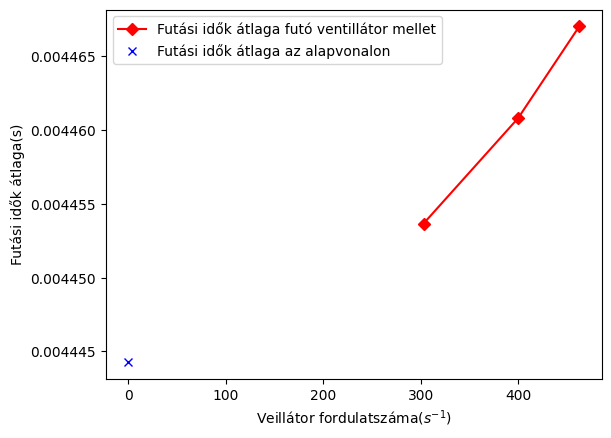

In [70]:
plt.plot(ventillator_fordulatszamok, doppler_atlagok * 1e-6, "rD-",  label="Futási idők átlaga futó ventillátor mellet")
plt.plot(0, meres_atlagok[0], "bx", label="Futási idők átlaga az alapvonalon")
plt.ylabel("Futási idők átlaga(s)")
plt.xlabel("Veillátor fordulatszáma($s^{-1}$)")
plt.legend()
plt.show()

In [71]:
def homerseklet_fuggo_szuro(x):
    x = x[x[:,3].argsort()]
    T_jelenlegi = x[:,3][0]
    szakaszok = []
    j = 0
    for i in range(len(x)):
        if x[:,3][i] != T_jelenlegi:
            T_jelenlegi = x[:,3][i]
            szakaszok.append(x[j:i])
            j = i
    eredmeny = []
    for i in range(len(szakaszok)):
        eredmeny.extend(szuro(szakaszok[i]))
    return eredmeny

In [72]:
melegites = np.loadtxt("./adatok/melegites.dat")

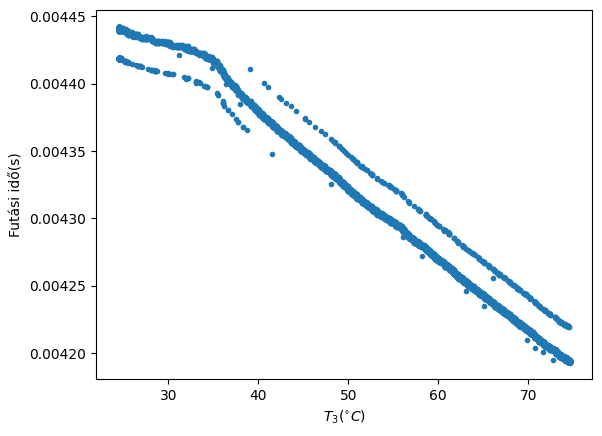

In [73]:
plt.plot(melegites[:,3] + 0.35, melegites[:,0] * 1e-6, ".")
plt.xlabel("$T_3$($^{\\circ}C$)")
plt.ylabel("Futási idő(s)")
plt.show()

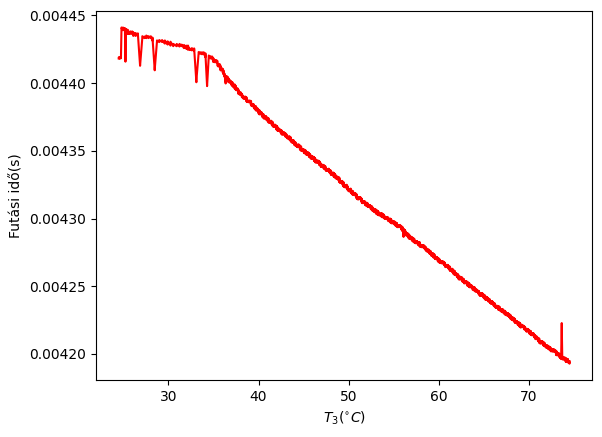

In [74]:
szurt_melegites = np.array(homerseklet_fuggo_szuro(melegites))
#print(szurt_melegites)
plt.plot(szurt_melegites[:,3] + 0.35, szurt_melegites[:,0] * 1e-6, c="r")
plt.xlabel("$T_3$($^{\\circ}C$)")
plt.ylabel("Futási idő(s)")
plt.show()

In [75]:
def homerseklet_sebesseg(T, c0, T0):
    T_3, T_4 = T
    return (0.248 + 0.231) / (c0 * np.sqrt((T_4 + T0)/T0)) + 1.0705 / (c0 * np.sqrt((T_3 + T0)/T0))

In [76]:
X = (szurt_melegites[:,3] + 0.35, szurt_melegites[:,4])

In [77]:
params = curve_fit(homerseklet_sebesseg, X, szurt_melegites[:,0] * 1e-6, p0=[330, 273])

In [78]:
print(params[0])
print(np.sqrt(np.diag(params[1])))

[333.44053252 277.95298082]
[0.03855776 0.44954033]


In [94]:
T = (np.linspace(20, 75, len(szurt_melegites)), szurt_melegites[:,4] - 0.43)
t = np.transpose(np.array([homerseklet_sebesseg(T, params[0][0], params[0][1])]))

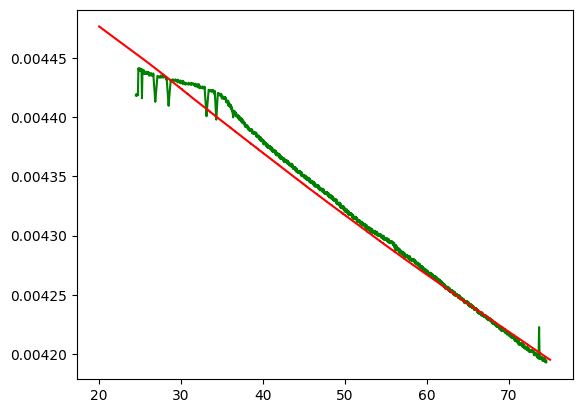

In [95]:
plt.plot(szurt_melegites[:,3] + 0.35, szurt_melegites[:,0] * 1e-6, c="green")
plt.plot(np.linspace(20, 75, len(szurt_melegites)), t, c="red")

In [96]:
melegites_40 = np.loadtxt("./adatok/melegites+40.dat")
szurt_40 = np.array(homerseklet_fuggo_szuro(melegites_40))
Y = (szurt_40[:,3] + 0.35, szurt_40[:,4] - 0.43)

In [82]:
p = curve_fit(homerseklet_sebesseg, Y, szurt_40[:,0] * 1e-6, p0=[330, 273])

In [83]:
print(p[0])
print(np.sqrt(np.diag(p[1])))

[332.5331669  267.48880183]
[0.01474021 0.15211779]


In [100]:
TT = (np.linspace(40, 75, len(szurt_40)), szurt_40[:,4] - 0.43)
tt = np.transpose(np.array([homerseklet_sebesseg(TT, p[0][0], p[0][1])]))

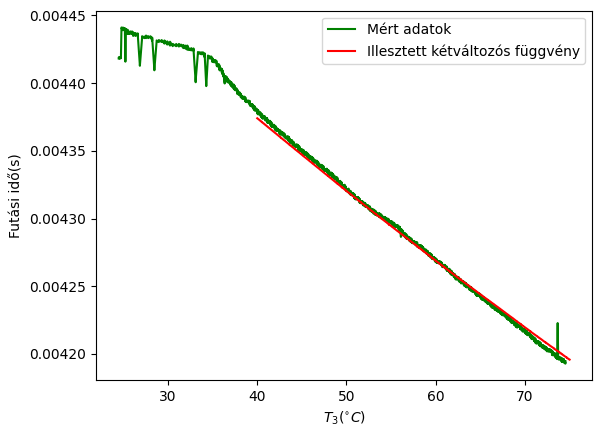

In [101]:
plt.plot(szurt_melegites[:,3] + 0.35, szurt_melegites[:,0] * 1e-6, c="green", label="Mért adatok")
plt.plot(np.linspace(40, 75, len(szurt_40)), tt, c="red", label="Illesztett kétváltozós függvény")
plt.legend()
plt.xlabel("$T_3(^{\\circ}C)$")
plt.ylabel("Futási idő(s)")
plt.show()

[http://resource.npl.co.uk/acoustics/techguides/speedair/](http://resource.npl.co.uk/acoustics/techguides/speedair/)

In [86]:
1/(12e-6)/2

41666.666666666664

In [87]:
print(np.average(ismerkedes[:,0])/1000)

4.4449544158150855


In [88]:
print(np.average(meresek[0][:,6]))

1013.8024880991737


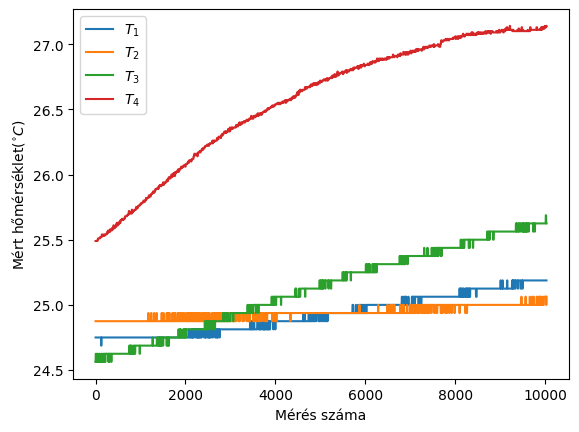

In [89]:
ventillator = np.loadtxt("./adatok/egyensuly.dat")
plt.plot(ventillator[:,1], label="$T_1$")
plt.plot(ventillator[:,2], label="$T_2$")
plt.plot(ventillator[:,3], label="$T_3$")
plt.plot(ventillator[:,4], label="$T_4$")
plt.legend()
plt.xlabel("Mérés száma")
plt.ylabel("Mért hőmérséklet($^{\\circ}C$)")
plt.show()

In [90]:
print(doppler_atlagok*1e-6)
print(doppler_szorasok*1e-6)

[0.00445365 0.00446078 0.00446701]
[8.58882055e-07 3.78699466e-07 1.07903934e-06]


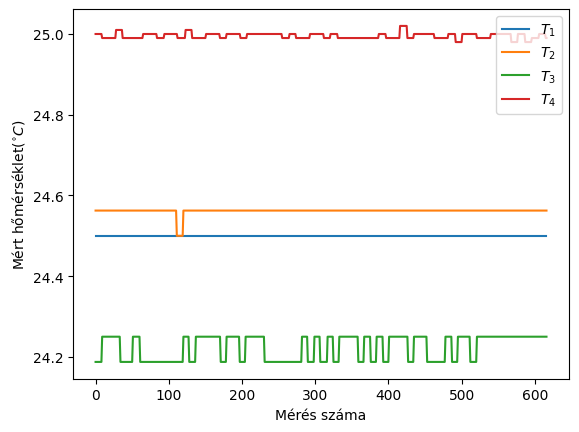

In [91]:
plt.plot(alapvonal[:,1], label="$T_1$")
plt.plot(alapvonal[:,2], label="$T_2$")
plt.plot(alapvonal[:,3], label="$T_3$")
plt.plot(alapvonal[:,4], label="$T_4$")
plt.legend()
plt.xlabel("Mérés száma")
plt.ylabel("Mért hőmérséklet($^{\\circ}C$)")
plt.show()

In [92]:
for i in range(1, 5):
    print(i, end=". & ")
    print(np.average(alapvonal[:,i]), end="")
    print("\\\\")

1. & 24.5\\
2. & 24.56158833063209\\
3. & 24.2234602917342\\
4. & 24.995251215559158\\


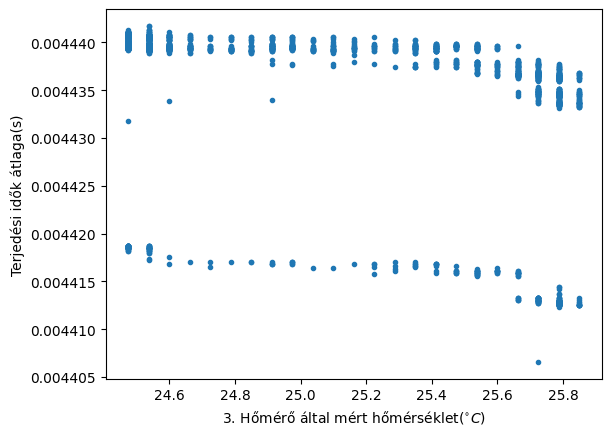

In [93]:
feltoltes = np.loadtxt("./adatok/feltoltes.dat")
plt.plot(feltoltes[:,3] + 0.35, feltoltes[:,0]*1e-6, ".")
plt.xlabel("3. Hőmérő által mért hőmérséklet($^{\\circ}C$)")
plt.ylabel("Terjedési idők átlaga(s)")
plt.show()